In [1]:
"""
ln(PRICE)=-9.53*** + 0.69∙ln(GH/s)*** – 0.98∙ln(COINS_PER_MIN)*** +7.46∙(ALGO)***
Significant Variables
Computational Power : GH/s
COINS_PER_Min : Block Reward/Time between Blocks
ALGO : SHA-256 (1) or anything else (Scrypt)
"""
import requests
import numpy as np
import pandas as pd
import datetime
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy import stats
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import statistics

from io import BytesIO
import statsmodels.api as sm

# NBER recessions
from pandas_datareader.data import DataReader

In [2]:
def expo_vol(prices):
    ma = []
    alpha = 2/(len(prices) + 1)
    ma.append(prices[0]**2)
    for i in range(1,len(prices),1) :
        ma.append(ma[i-1] +alpha*(prices[i]**2-ma[i-1]))

    return ma 

In [3]:
MarketPriceData = requests.get("https://api.blockchain.info/charts/market-price?timespan=10year&format=json&sampled=false")  # BTC Price is USD for 1 year
MarketPriceData.status_code

MarketPriceData_df = pd.DataFrame(MarketPriceData.json())
MarketPriceData_df['Market Price'] = [MarketPriceData_df['values'][i]['y'] for i in range(0,len(MarketPriceData_df),1)]
MarketPriceData_df['TimeStamp'] = [datetime.datetime.fromtimestamp(MarketPriceData_df['values'][i]['x']) for i in range(0,len(MarketPriceData_df),1)]
MarketPriceData_df['EWMA_Vol'] = expo_vol(MarketPriceData_df['Market Price'])
MarketPriceData_df

,status,name,unit,period,description,values,Market Price,TimeStamp,EWMA_Vol
0,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1443657600, 'y': 236.17}",236.17,2015-10-01 01:00:00,5.577627e+04
1,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1443744000, 'y': 238.03}",238.03,2015-10-02 01:00:00,5.577675e+04
2,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1443830400, 'y': 237.77}",237.77,2015-10-03 01:00:00,5.577717e+04
3,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1443916800, 'y': 239.09}",239.09,2015-10-04 01:00:00,5.577793e+04
4,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1444003200, 'y': 238.4}",238.40,2015-10-05 01:00:00,5.577851e+04
...,...,...,...,...,...,...,...,...,...
3646,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1758672000, 'y': 112010.28}",112010.28,2025-09-24 01:00:00,2.595748e+09
3647,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1758758400, 'y': 113316.86}",113316.86,2025-09-25 01:00:00,2.601358e+09
3648,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1758844800, 'y': 109036.72}",109036.72,2025-09-26 01:00:00,2.606445e+09
3649,ok,Market Price (USD),USD,day,Average USD market price across major bitcoin ...,"{'x': 1758931200, 'y': 109698.86}",109698.86,2025-09-27 01:00:00,2.611608e+09


In [4]:
HashrateData =  requests.get("https://api.blockchain.info/charts/hash-rate?timespan=10years&format=json&sampled=false") #Computational Power in GH/s for 1 year
HashrateData.status_code

HashrateData_df = pd.DataFrame(HashrateData.json())

HashrateData_df['HashRate']  = [HashrateData_df['values'][i]['y'] for i in range(0,len(HashrateData_df),1)] 
HashrateData_df['TimeStamp'] = [datetime.datetime.fromtimestamp(HashrateData_df['values'][i]['x']) for i in range(0,len(HashrateData_df),1)]
HashrateData_df  

,status,name,unit,period,description,values,HashRate,TimeStamp
0,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1443657600, 'y': 465548.431663339}",4.655484e+05,2015-10-01 01:00:00
1,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1443744000, 'y': 377880.220505957}",3.778802e+05,2015-10-02 01:00:00
2,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1443830400, 'y': 459502.348135243}",4.595023e+05,2015-10-03 01:00:00
3,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1443916800, 'y': 456479.306371196}",4.564793e+05,2015-10-04 01:00:00
4,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1444003200, 'y': 447410.181079053}",4.474102e+05,2015-10-05 01:00:00
...,...,...,...,...,...,...,...,...
3645,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1758585600, 'y': 1018928040.676955}",1.018928e+09,2025-09-23 01:00:00
3646,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1758672000, 'y': 1082611043.2192645}",1.082611e+09,2025-09-24 01:00:00
3647,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1758758400, 'y': 997700373.1628518}",9.977004e+08,2025-09-25 01:00:00
3648,ok,Hash Rate,Hash Rate TH/s,day,The estimated number of tera hashes per second...,"{'x': 1758844800, 'y': 934017370.6205422}",9.340174e+08,2025-09-26 01:00:00


In [5]:
BlockDifficulty = requests.get("https://api.blockchain.info/charts/difficulty?timespan=10years&format=json&sampled=false") #Relative Difficulty of mining
BlockDifficulty.status_code  

BlockDifficulty_df = pd.DataFrame(BlockDifficulty.json()) 

BlockDifficulty_df['Difficulty'] = [BlockDifficulty_df['values'][i]['y'] for i in range(0,len(BlockDifficulty_df),1) ]   
BlockDifficulty_df['Timestamp'] =  [datetime.datetime.fromtimestamp(BlockDifficulty_df['values'][i]['x']) for i  in range(0,len(BlockDifficulty_df),1) ]
BlockDifficulty_df

,status,name,unit,period,description,values,Difficulty,Timestamp
0,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1443657600, 'y': 60813224039.4403}",6.081322e+10,2015-10-01 01:00:00
1,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1443744000, 'y': 60813224039.4403}",6.081322e+10,2015-10-02 01:00:00
2,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1443830400, 'y': 60813224039.4403}",6.081322e+10,2015-10-03 01:00:00
3,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1443916800, 'y': 60813224039.4403}",6.081322e+10,2015-10-04 01:00:00
4,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1444003200, 'y': 60813224039.4403}",6.081322e+10,2015-10-05 01:00:00
...,...,...,...,...,...,...,...,...
3645,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1758585600, 'y': 142342602928675.56}",1.423426e+14,2025-09-23 01:00:00
3646,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1758672000, 'y': 142342602928675.6}",1.423426e+14,2025-09-24 01:00:00
3647,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1758758400, 'y': 142342602928675.53}",1.423426e+14,2025-09-25 01:00:00
3648,ok,Difficulty,Difficulty,day,A relative measure of how difficult it is to f...,"{'x': 1758844800, 'y': 142342602928675.5}",1.423426e+14,2025-09-26 01:00:00


In [6]:
MinersRevenue = requests.get("https://api.blockchain.info/charts/miners-revenue?timespan=10years&format=json&sampled=false")   #Miners Revenue : Total value in USD of coinbase block rewards and transaction fees paid to miners.

MinersRevenue.status_code  

MinersRevenue_df = pd.DataFrame(MinersRevenue.json())

MinersRevenue_df['MinerRevenue'] = [MinersRevenue_df['values'][i]['y'] for i in range(0,len(MinersRevenue_df),1) ]   
MinersRevenue_df['Timestamp'] =  [datetime.datetime.fromtimestamp(MinersRevenue_df['values'][i]['x']) for i  in range(0,len(MinersRevenue_df),1) ]
MinersRevenue_df

,status,name,unit,period,description,values,MinerRevenue,Timestamp
0,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1443657600, 'y': 1034425.38573053}",1.034425e+06,2015-10-01 01:00:00
1,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1443744000, 'y': 874869.524902395}",8.748695e+05,2015-10-02 01:00:00
2,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1443830400, 'y': 1015435.61556746}",1.015436e+06,2015-10-03 01:00:00
3,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1443916800, 'y': 991818.86960847}",9.918189e+05,2015-10-04 01:00:00
4,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1444003200, 'y': 1004466.6374232}",1.004467e+06,2015-10-05 01:00:00
...,...,...,...,...,...,...,...,...
3645,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1758585600, 'y': 51049596.047497146}",5.104960e+07,2025-09-23 01:00:00
3646,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1758672000, 'y': 55101523.83746149}",5.510152e+07,2025-09-24 01:00:00
3647,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1758758400, 'y': 50173577.36223641}",5.017358e+07,2025-09-25 01:00:00
3648,ok,Miners Revenue,USD,day,Total value of coinbase block rewards and tran...,"{'x': 1758844800, 'y': 49131500.76535409}",4.913150e+07,2025-09-26 01:00:00


split data:
pre 2015
post 2015
fitness of model check
regime change
vol of prices : trend
if the model holds: we can conclude that price beahviour is similar to Commodity

In [7]:
df1 = MinersRevenue_df[['Timestamp','MinerRevenue']].merge(BlockDifficulty_df[['Timestamp','Difficulty']], how='inner',on='Timestamp')
df1 = df1.rename(columns={'Timestamp':'TimeStamp'})
df2 = MarketPriceData_df[['TimeStamp','Market Price']].merge(HashrateData_df[['TimeStamp','HashRate']], how='inner',on='TimeStamp')

df3 = df1.merge(df2,how='inner',on='TimeStamp')
df3['MinerRevenue(BTC)'] =  df3["MinerRevenue"].div(df3["Market Price"].values) 
   
df3

,TimeStamp,MinerRevenue,Difficulty,Market Price,HashRate,MinerRevenue(BTC)
0,2015-10-01 01:00:00,1.034425e+06,6.081322e+10,236.17,4.655484e+05,4380.003327
1,2015-10-02 01:00:00,8.748695e+05,6.081322e+10,238.03,3.778802e+05,3675.459080
2,2015-10-03 01:00:00,1.015436e+06,6.081322e+10,237.77,4.595023e+05,4270.663311
3,2015-10-04 01:00:00,9.918189e+05,6.081322e+10,239.09,4.564793e+05,4148.307623
4,2015-10-05 01:00:00,1.004467e+06,6.081322e+10,238.40,4.474102e+05,4213.366768
...,...,...,...,...,...,...
3645,2025-09-23 01:00:00,5.104960e+07,1.423426e+14,112752.31,1.018928e+09,452.758760
3646,2025-09-24 01:00:00,5.510152e+07,1.423426e+14,112010.28,1.082611e+09,491.932739
3647,2025-09-25 01:00:00,5.017358e+07,1.423426e+14,113316.86,9.977004e+08,442.772394
3648,2025-09-26 01:00:00,4.913150e+07,1.423426e+14,109036.72,9.340174e+08,450.595916


In [8]:
import yfinance as yf
data = yf.download("^GSPC", start=min(df3['TimeStamp']), end= max(df3['TimeStamp']))

data = data.reset_index(drop=False)
data

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21980\1828241734.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^GSPC", start=min(df3['TimeStamp']), end= max(df3['TimeStamp']))
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
0,2015-10-01,1923.819946,1927.209961,1900.699951,1919.650024,3983600000
1,2015-10-02,1951.359985,1951.359985,1893.699951,1921.770020,4378570000
2,2015-10-05,1987.050049,1989.170044,1954.329956,1954.329956,4334490000
3,2015-10-06,1979.920044,1991.619995,1971.989990,1986.630005,4202400000
4,2015-10-07,1995.829956,1999.310059,1976.439941,1982.339966,4666470000
...,...,...,...,...,...,...
2507,2025-09-22,6693.750000,6698.879883,6648.069824,6654.279785,5642620000
2508,2025-09-23,6656.919922,6699.520020,6645.580078,6692.439941,5633620000
2509,2025-09-24,6637.970215,6672.660156,6621.759766,6669.790039,5459180000


In [17]:
# Flatten columns in data
data.columns = [col[0] if isinstance(col, tuple) else col for col in data.columns]

# Convert both columns to datetime.date for matching
df3['TimeStamp'] = pd.to_datetime(df3['TimeStamp']).dt.date
data['Date'] = pd.to_datetime(data['Date']).dt.date

# Now merge
CorrData = df3[['TimeStamp','Market Price']].merge(data[['Date','Close']], how='inner', left_on='TimeStamp', right_on='Date')
CorrData

,TimeStamp,Market Price,Date,Close
0,2015-10-01,236.17,2015-10-01,1923.819946
1,2015-10-02,238.03,2015-10-02,1951.359985
2,2015-10-05,238.40,2015-10-05,1987.050049
3,2015-10-06,240.60,2015-10-06,1979.920044
4,2015-10-07,246.80,2015-10-07,1995.829956
...,...,...,...,...
2507,2025-09-22,115317.03,2025-09-22,6693.750000
2508,2025-09-23,112752.31,2025-09-23,6656.919922
2509,2025-09-24,112010.28,2025-09-24,6637.970215
2510,2025-09-25,113316.86,2025-09-25,6604.720215


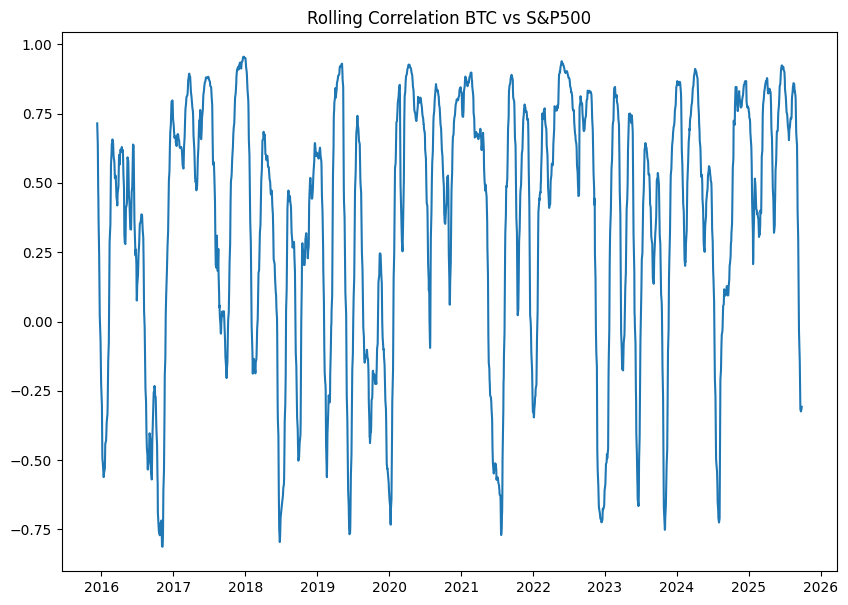

In [19]:
import statistics
rollingCorr = []
w =50
for t in range(len(CorrData)-w):
    subSer = df3['Market Price'][t:t+w]
    corr_matrix = np.corrcoef(CorrData['Market Price'][t:t+w], CorrData['Close'][t:t+w])
    CorrData.loc[t+w,'RollingCorr'] = corr_matrix[0][1] 
    #rollingVol.append(vol_i)


fig, ax1 = plt.subplots(figsize=(10,7))
plt.plot(CorrData['TimeStamp'], CorrData['RollingCorr'])
ax1.set(title="Rolling Correlation BTC vs S&P500")
plt.show()

In [20]:
df3['Market Price']
MarketPrices = df3['Market Price']
ExogVariables = df3[['Difficulty','HashRate','MinerRevenue(BTC)']]
ExogVariables.index = pd.DatetimeIndex(df3.TimeStamp)
ExogVariables = ExogVariables.resample('BMS', convention='end').asfreq().bfill()
MarketPrices.index = pd.DatetimeIndex(df3.TimeStamp)
MarketPrices = MarketPrices.resample('BMS', convention='end').asfreq().bfill()
MarketPrices
ExogVariables

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21980\4064551345.py:5: FutureWarning: The 'convention' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast PeriodIndex to DatetimeIndex before resampling instead.
  ExogVariables = ExogVariables.resample('BMS', convention='end').asfreq().bfill()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_21980\4064551345.py:7: FutureWarning: The 'convention' keyword in Series.resample is deprecated and will be removed in a future version. Explicitly cast PeriodIndex to DatetimeIndex before resampling instead.
  MarketPrices = MarketPrices.resample('BMS', convention='end').asfreq().bfill()


,Difficulty,HashRate,MinerRevenue(BTC)
TimeStamp,,,
2015-10-01,6.081322e+10,4.655484e+05,4380.003327
2015-11-02,6.225398e+10,4.487260e+05,4482.051515
2015-12-01,7.272278e+10,6.940933e+05,4670.945656
2016-01-01,1.038803e+11,6.971292e+05,3608.273011
2016-02-01,1.200333e+11,1.050173e+06,4386.900445
...,...,...,...
2025-05-01,1.232344e+14,8.270120e+08,434.567405
2025-06-02,1.269823e+14,8.395390e+08,416.484770
2025-07-01,1.169585e+14,7.790812e+08,427.588236


<b> Hamilton (1989) switching model </b>

The model can be written as:


$ y_{t} = a_{S_t} + x_t\beta_{S_t} + \phi_{1, S_t}
        (y_{t-1} - a_{S_{t-1}} - x_{t-1}) \beta_{S_{t-1}} + \dots +
        \phi_{p, S_t} (y_{t-p} - a_{S_{t-p}} - x_{t-p}) \beta_{S_{t-p}} +
        \varepsilon_t \\
        \varepsilon_t \sim N(0, \sigma_{S_t}^2)$

    i.e. the model is an autoregression with where the autoregressive
    coefficients, the mean of the process (possibly including trend or
    regression effects) and the variance of the error term may be switching
    across regimes.

    The `trend` is accommodated by prepending columns to the `exog` array. Thus
    if `trend='c'`, the passed `exog` array should not already have a column of
    ones.

    References
    ----------
    Kim, Chang-Jin, and Charles R. Nelson. 1999.
    "State-Space Models with Regime Switching:
    Classical and Gibbs-Sampling Approaches with Applications".
    MIT Press Books. The MIT Press.
    """

The Markov Switching Autoregression with exogenous variables (MS-ARX) is estimated as:

$
y_{t} = c_{S_t} + \phi_1 y_{t-1} $
 $+ \beta_{1,S_t} \cdot \text{Difficulty}_t $
 $+ \beta_2 \cdot \text{HashRate}_t $
 $+ \beta_3 \cdot \text{MinerRevenue}_t $
 $+ \varepsilon_t$


where:


- $y_t$: Bitcoin price at time $t$  
- $c_{S_t}$: regime-dependent intercept (varies by regime $S_t$)  
- $\phi_1$: AR(1) coefficient (non-switching)  
- $\beta_{1,S_t}$: regime-dependent coefficient for Difficulty  
- $\beta_2$: fixed coefficient for HashRate  
- $\beta_3$: fixed coefficient for MinerRevenue  
- $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$: error term  
- $S_t \in \{0,1\}$: hidden regime, evolving via a 2-state Markov chain

In [35]:
from datetime import datetime
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm

# NBER recessions
from pandas_datareader.data import DataReader

'''
MarketPrices = df3['Market Price']
MarketPrices.index = pd.DatetimeIndex(df3.TimeStamp)
'''
ExogVariables = (ExogVariables - ExogVariables.mean()) / ExogVariables.std()

mod_hamilton = sm.tsa.MarkovAutoregression(
    MarketPrices, k_regimes=2, order=1,exog=ExogVariables,
 switching_ar=False,switching_exog=[True, False, False]
)
res_hamilton = mod_hamilton.fit()
#res_hamilton.filtered_marginal_probabilities
res_hamilton.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         Markov Switching Model Results                         
================================================================================
Dep. Variable:             Market Price   No. Observations:                  119
Model:             MarkovAutoregression   Log Likelihood               -1195.187
Date:                  Sun, 28 Sep 2025   AIC                           2410.373
Time:                          14:04:58   BIC                           2438.164
Sample:                      10-01-2015   HQIC                          2421.658
                           - 09-01-2025                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.373e+04   6227.349      3.811      0.000    1.15e+04    3.59e+04
x1         -3953.8881   7555.396     -0.523      0.601   -1.88e+04    1.09e+04
                             Regime 1 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.042e+04   6127.503      4.964      0.000    1.84e+04    4.24e+04
x1          5207.3063   6579.047      0.791      0.429   -7687.389    1.81e+04
                           Non-switching parameters                           
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x2           2.12e+04   5311.094      3.991      0.000    1.08e+04    3.16e+04
x3          -212.1823   1483.318     -0.143      0.886   -3119.432    2695.067
sigma2      2.614e+07      8.110   3.22e+06      0.000    2.61e+07    2.61e+07
ar.L1          0.9124      0.042     21.942      0.000       0.831       0.994
                         Regime transition parameters                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
p[0->0]        0.7320      0.319      2.295      0.022       0.107       1.357
p[1->0]        0.0851      0.098      0.870      0.385      -0.107       0.277
==============================================================================

Warnings:
[1] Covariance matrix calculated using numerical (complex-step) differentiation.
[2] Covariance matrix is singular or near-singular, with condition number 3.6e+22. Standard errors may be unstable.
"""

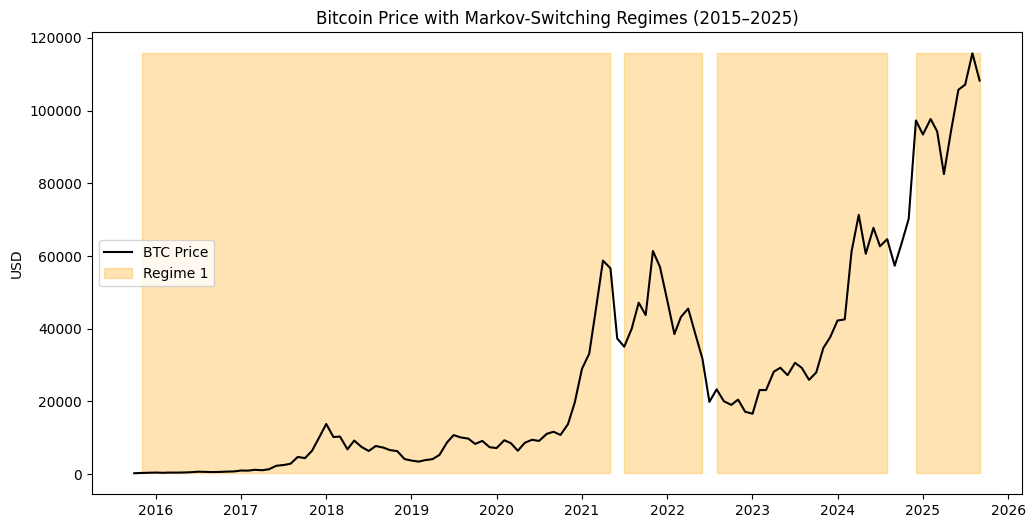

In [ ]:
# Smoothed probabilities of being in Regime 1
probs = res_hamilton.smoothed_marginal_probabilities[1]

probs = probs.reindex(MarketPrices.index, method="ffill")

fig, ax = plt.subplots(figsize=(12, 6))

# Plot BTC price
ax.plot(MarketPrices.index, MarketPrices, label="BTC Price", color="black")

# Shade Regime 1 (probability > 0.5)
ax.fill_between(
    MarketPrices.index, MarketPrices.min(), MarketPrices.max(),
    where=probs > 0.5, color="orange", alpha=0.3, label="Regime 1"
)

ax.set_title("Bitcoin Price with Markov-Switching Regimes (2015–2025)")
ax.set_ylabel("USD")
ax.legend()
plt.show()

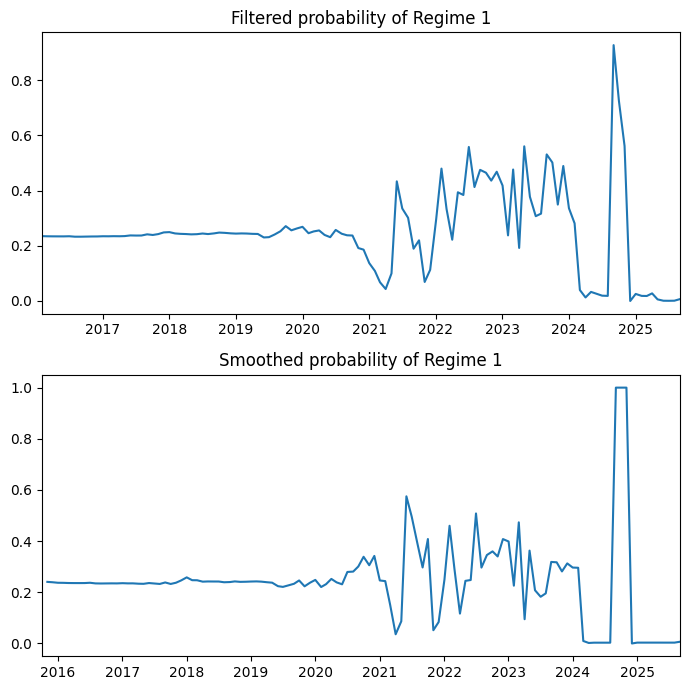

In [38]:
fig, axes = plt.subplots(2, figsize=(7, 7))
ax = axes[0]
ax.plot(res_hamilton.filtered_marginal_probabilities[0])

#ax.fill_between(MarketPrices.index, 0, 1, where=usrec["USREC"].values, color="k", alpha=0.1)
ax.set_xlim(MarketPrices.index[4], MarketPrices.index[-1])
ax.set(title="Filtered probability of Regime 1")

ax = axes[1]
ax.plot(res_hamilton.smoothed_marginal_probabilities[0])
#ax.fill_between(usrec.index, 0, 1, where=usrec["USREC"].values, color="k", alpha=0.1)
ax.set_xlim(MarketPrices.index[0], MarketPrices.index[-1])
ax.set(title="Smoothed probability of Regime 1")

fig.tight_layout()

- *Regime 0 corresponds to a low-growth, consolidation phase, with lower intercept and weaker fundamentals.*  

- *Regime 1 corresponds to a high-growth or bullish phase, where the BTC price is higher and hashrate fundamentals matter more.*  

We want to introduce volatility as a factor and check

In [41]:
# Compute log returns
MarketReturns = np.log(MarketPrices).diff().dropna()

# Align exogenous variables (optional: lagged or differences if needed)
ExogReturns = ExogVariables.pct_change().dropna()
MarketReturns = MarketReturns.loc[ExogReturns.index]

mod = sm.tsa.MarkovAutoregression(
    MarketReturns,
    k_regimes=2,
    order=1,                  # AR(1) on returns is usually enough
    exog=ExogReturns,         # optional
    switching_ar=False,       # AR coefficient same across regimes
    switching_variance=True   # now volatility changes by regime
)
res = mod.fit()
print(res.summary())

                         Markov Switching Model Results                         
Dep. Variable:             Market Price   No. Observations:                  118
Model:             MarkovAutoregression   Log Likelihood                  46.401
Date:                  Sun, 28 Sep 2025   AIC                            -72.802
Time:                          14:19:18   BIC                            -45.096
Sample:                      11-02-2015   HQIC                           -61.553
                           - 09-01-2025                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0906      0.001   -114.638      0.000      -0.092      -0.089
sigma2      3.619e-07        nan    

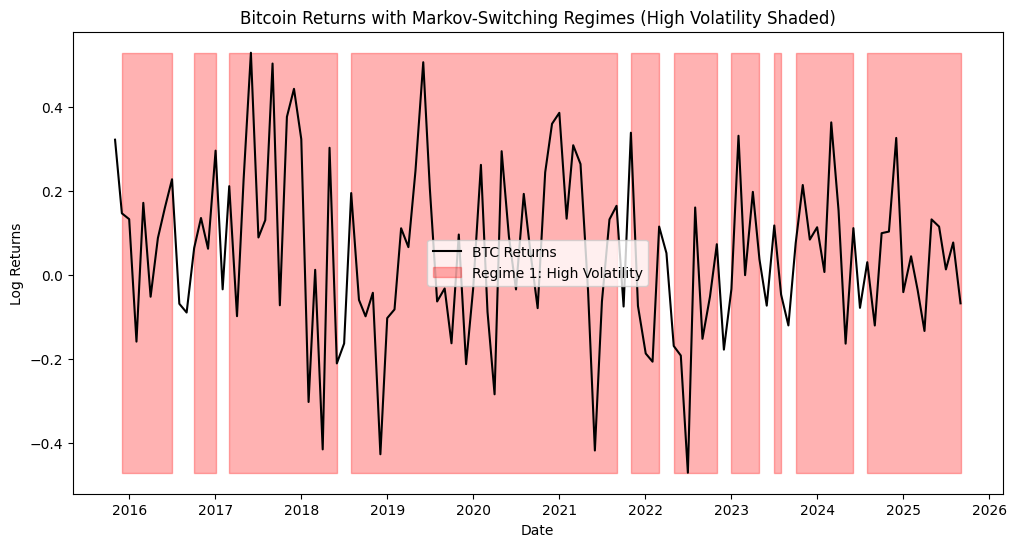

In [42]:
probs = res.smoothed_marginal_probabilities[1]

# Align probability series with returns index (in case of minor length mismatch)
probs = probs.reindex(MarketReturns.index, method="ffill")

fig, ax = plt.subplots(figsize=(12, 6))

# Plot BTC returns
ax.plot(MarketReturns.index, MarketReturns, label="BTC Returns", color="black")

# Shade high-volatility periods (Regime 1 probability > 0.5)
ax.fill_between(
    MarketReturns.index, 
    MarketReturns.min(), 
    MarketReturns.max(),
    where=probs > 0.5, 
    color="red", alpha=0.3, 
    label="Regime 1: High Volatility"
)

ax.set_title("Bitcoin Returns with Markov-Switching Regimes (High Volatility Shaded)")
ax.set_ylabel("Log Returns")
ax.set_xlabel("Date")
ax.legend()
plt.show()

In [46]:
# Smoothed probabilities of being in Regime 1 (high volatility)
probs = res.smoothed_marginal_probabilities[1]
probs = probs.reindex(MarketReturns.index, method="ffill")

# Regime 1 = high-volatility, Regime 0 = low-volatility
high_vol = probs
low_vol = 1 - probs

# Align exogenous variables (optional: lagged or differences if needed)
ExogReturns = ExogVariables.pct_change().dropna()

# Align with MarketReturns index
ExogReturns = ExogReturns.loc[MarketReturns.index]
# Weighted average of exogenous variables in each regime
avg_high_vol = (ExogReturns * high_vol.to_numpy()[:, None]).sum() / high_vol.sum()
avg_low_vol = (ExogReturns * low_vol.to_numpy()[:, None]).sum() / low_vol.sum()

print("Average Exogenous Variables in High-Volatility Regime (Regime 1):")
print(avg_high_vol)
print("\nAverage Exogenous Variables in Low-Volatility Regime (Regime 0):")
print(avg_low_vol)

Average Exogenous Variables in High-Volatility Regime (Regime 1):
Difficulty           0.095685
HashRate            -0.025065
MinerRevenue(BTC)    0.074874
dtype: float64

Average Exogenous Variables in Low-Volatility Regime (Regime 0):
Difficulty          -0.008801
HashRate            -1.084659
MinerRevenue(BTC)   -0.028142
dtype: float64


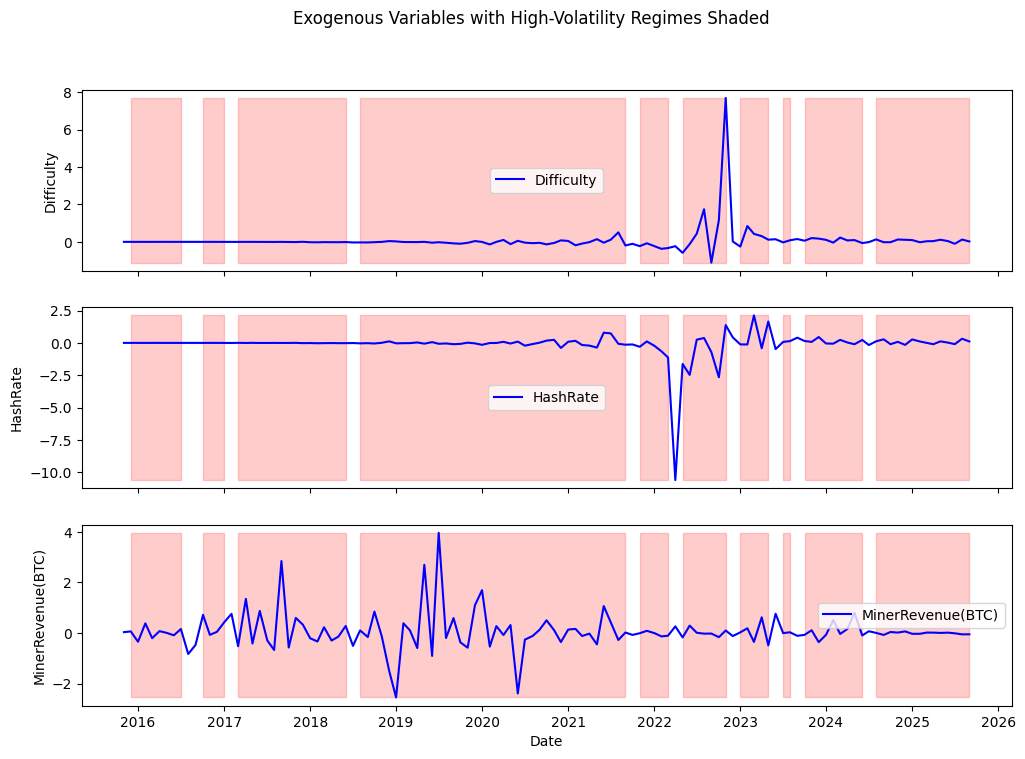

In [48]:
fig, axes = plt.subplots(len(ExogReturns.columns), 1, figsize=(12, 8), sharex=True)

for i, col in enumerate(ExogReturns.columns):
    axes[i].plot(ExogReturns.index, ExogReturns[col], label=col, color='blue')
    axes[i].fill_between(
        MarketReturns.index, 
        ExogReturns[col].min(), 
        ExogReturns[col].max(),
        where=probs > 0.5, 
        color='red', alpha=0.2
    )
    axes[i].set_ylabel(col)
    axes[i].legend()

axes[-1].set_xlabel("Date")
fig.suptitle("Exogenous Variables with High-Volatility Regimes Shaded")
plt.show()

Some Useful Plots



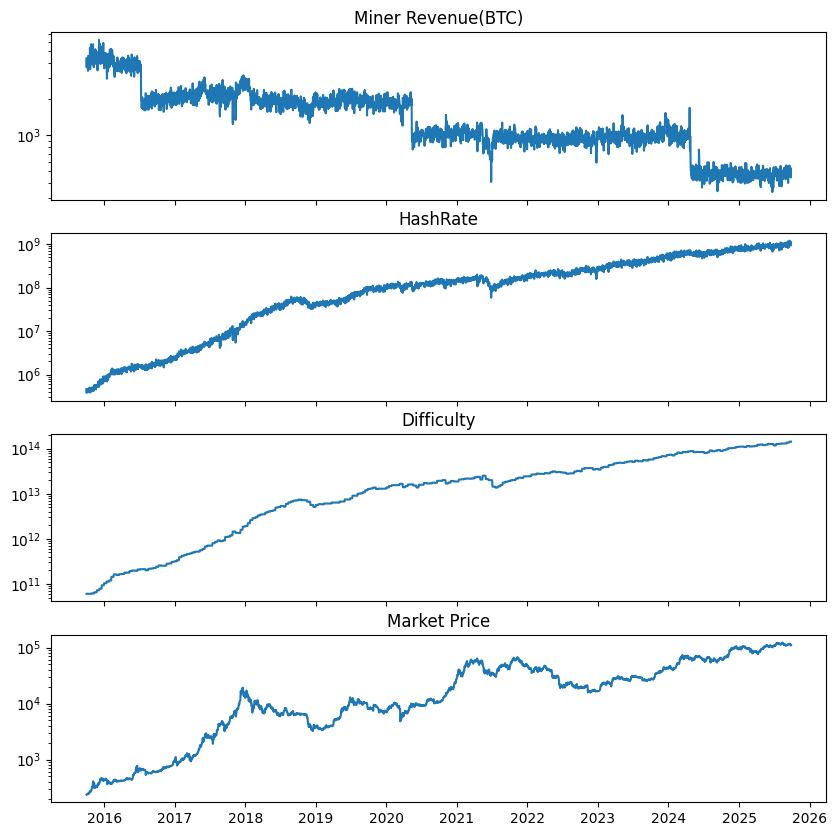

In [39]:
fig,axs = plt.subplots(4,sharex=True,figsize=(10,10))

axs[0].plot(df3['TimeStamp'],df3['MinerRevenue(BTC)'],label='MinerRevenue')
axs[0].set_title('Miner Revenue(BTC)')
axs[0].set_yscale('log')

axs[1].plot(df3['TimeStamp'],df3['HashRate'],label='HashRate')
axs[1].set_title('HashRate')
axs[1].set_yscale('log')

axs[2].plot(df3['TimeStamp'],df3['Difficulty'],label='Difficulty')
axs[2].set_title('Difficulty')
axs[2].set_yscale('log')

axs[3].plot(df3['TimeStamp'],df3['Market Price'],label='Market Price')
axs[3].set_title('Market Price')
axs[3].set_yscale('log')


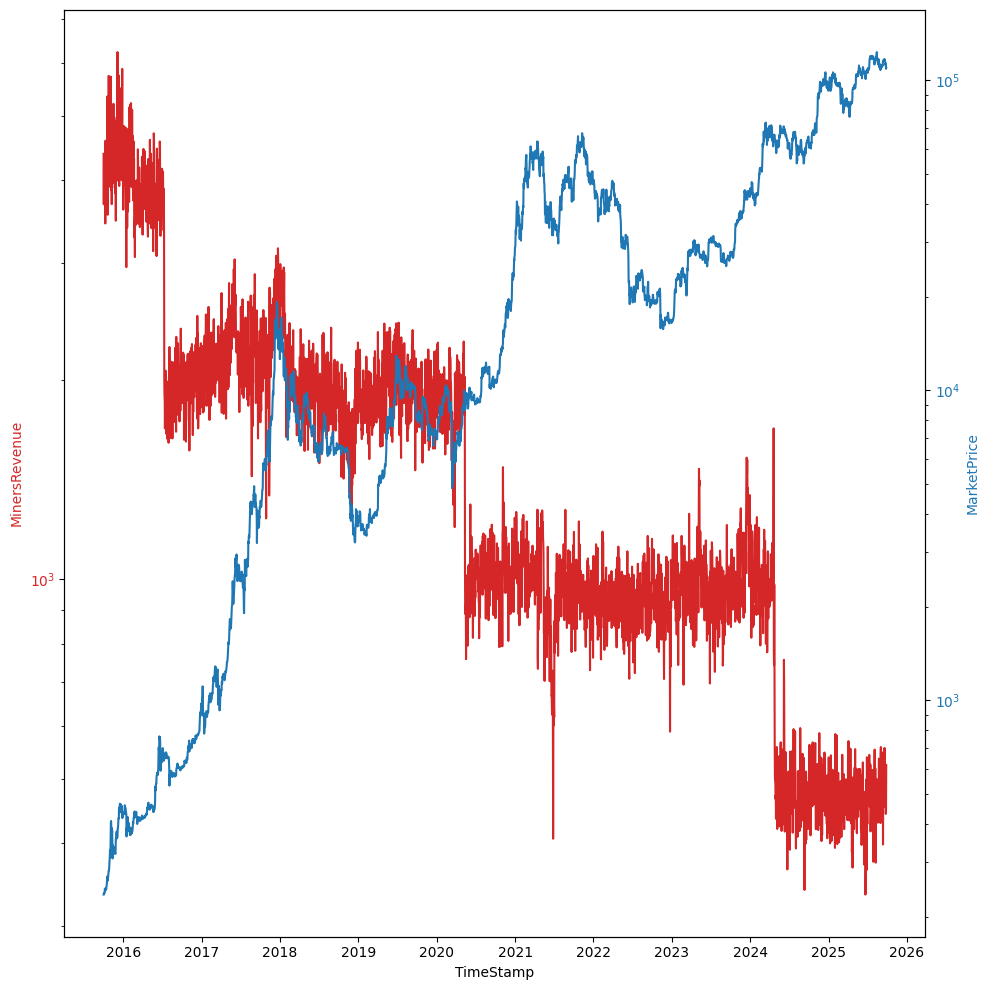

In [30]:
fig, ax1 = plt.subplots(figsize=(10,10))

color = 'tab:red'
ax1.set_xlabel('TimeStamp')
ax1.set_ylabel('MinersRevenue', color=color)
ax1.plot(df3['TimeStamp'],df3['MinerRevenue(BTC)'],label='MinerRevenue',color=color) 
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('MarketPrice', color=color)  # we already handled the x-label with ax1
ax2.plot(df3['TimeStamp'],df3['Market Price'], color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

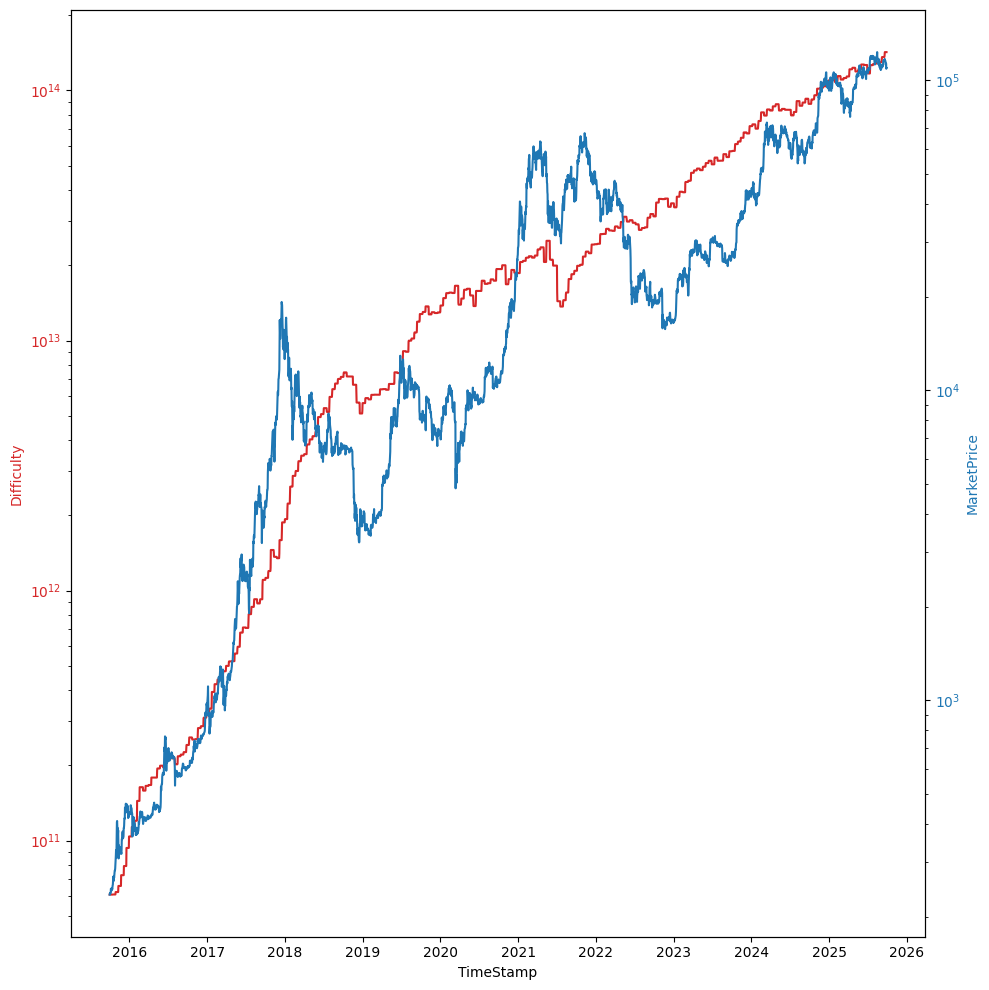

In [31]:
fig, ax1 = plt.subplots(figsize=(10,10))

color = 'tab:red'
ax1.set_xlabel('TimeStamp')
ax1.set_ylabel('Difficulty', color=color)
ax1.plot(df3['TimeStamp'],df3['Difficulty'],label='MinerRevenue',color=color) 
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('MarketPrice', color=color)  # we already handled the x-label with ax1
ax2.plot(df3['TimeStamp'],df3['Market Price'], color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

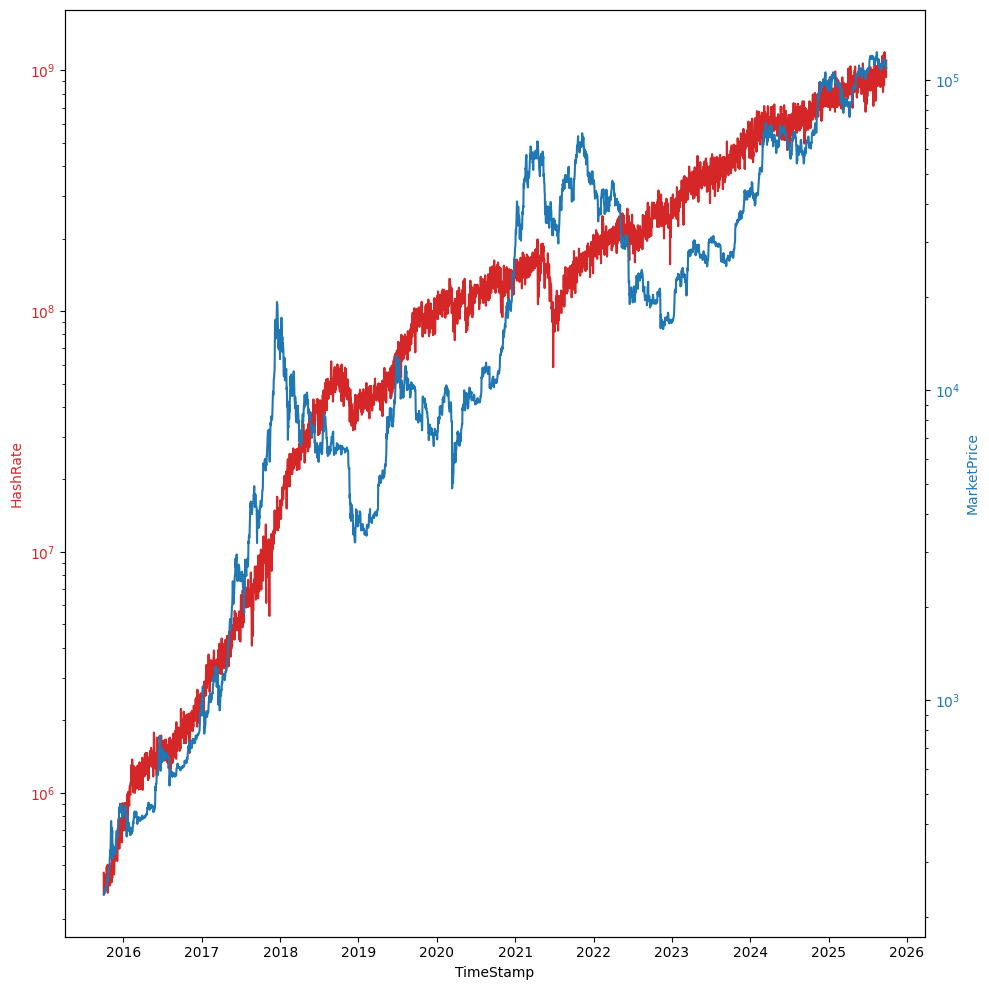

In [32]:
fig, ax1 = plt.subplots(figsize=(10,10))

color = 'tab:red'
ax1.set_xlabel('TimeStamp')
ax1.set_ylabel('HashRate', color=color)
ax1.plot(df3['TimeStamp'],df3['HashRate'],label='MinerRevenue',color=color) 
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('MarketPrice', color=color)  # we already handled the x-label with ax1
ax2.plot(df3['TimeStamp'],df3['Market Price'], color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

<b> Rolling Window Vol vs Timestamp </b>

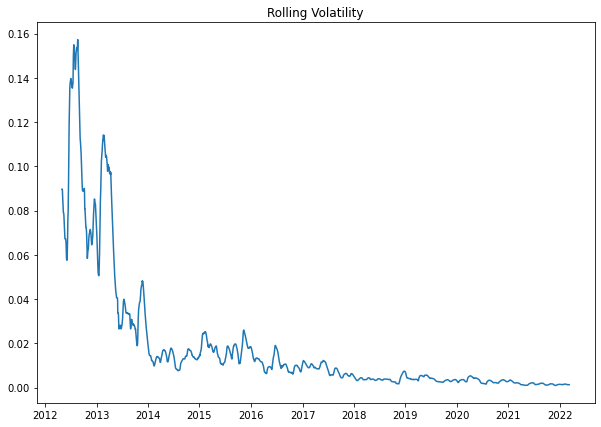

In [71]:
import statistics

rollingVol = []
w = 50       #Rolling Window Length
for t in range(len(df3)-w):
    subSer = df3['Market Price'][t:t+ w]
    mean_i = np.mean(subSer)
    vol_i = (np.sum((subSer - mean_i)**2) / len(subSer))**0.5
    df3.loc[t+w,'RollingVol'] = np.sqrt(vol_i)/mean_i
    #rollingVol.append(vol_i)

df3

fig, ax1 = plt.subplots(figsize=(10,7))
plt.plot(df3['TimeStamp'], df3['RollingVol'])
ax1.set(title="Rolling Volatility")
plt.show()

<b> Finding Optimal Pivot Date based on $R^{2}$ diff between regimes  </b>

In [67]:
 from datetime import datetime,timedelta
#FitScaler
def FitScaler(data):
    scaler = StandardScaler()
    scaler.fit(data)
    # scale data set
    Xt = scaler.transform(data)
    Scaled_Xt = pd.DataFrame(Xt, columns =data.columns)

    X = sm.add_constant(Scaled_Xt)
    return X

#Finding Optimal Pivot Point
maxRsqaurediff = 0
OptimalPivotDate = datetime.strptime( "2016-1-1", '%Y-%m-%d')
pivot_date = datetime.strptime( "2016-1-1", '%Y-%m-%d')

firstRegimeRsquaredList = []
secondRegimeRsquaredList = []
pivotDateList = []

while(pivot_date < datetime.strptime( "2021-11-30", '%Y-%m-%d')):
    pivotDateList.append(pivot_date)  
    firstRegime = df3.loc[(df3["TimeStamp"] < pivot_date) & (df3["TimeStamp"] > (pivot_date - timedelta(days=200)))]
    firstRegime.reset_index(drop=True)
    
    secondRegime = df3.loc[(df3["TimeStamp"] > pivot_date) & (df3["TimeStamp"] < (pivot_date + timedelta(days=200)))]
    secondRegime.reset_index(drop=True)

    firstX = np.log(firstRegime[['MinerRevenue(BTC)','Difficulty','HashRate']])
    firstY = np.log(firstRegime['Market Price']).reset_index(drop=True)

    secondX = np.log(secondRegime[['MinerRevenue(BTC)','Difficulty','HashRate']])
    secondY = np.log(secondRegime['Market Price'].reset_index(drop=True))

    firstScaledX = FitScaler(firstX)
    res = sm.OLS(firstY, firstScaledX).fit()
    firstRegimeRsquared = res.rsquared
    firstRegimeRsquaredList.append(firstRegimeRsquared)
    
    secondScaledX = FitScaler(secondX)
    res = sm.OLS(secondY, secondScaledX).fit()
    secondRegimeRsquared = res.rsquared
    secondRegimeRsquaredList.append(secondRegimeRsquared)
    
    Rsquarediff = firstRegimeRsquared - secondRegimeRsquared
    if Rsquarediff >maxRsqaurediff:
        OptimalPivotDate = pivot_date
        maxRsqaurediff = Rsquarediff
   # print(pivot_date,":" ,Rsquarediff)
    pivot_date =  pivot_date + timedelta(days=1)
   
    
print("Optimal Regime Shift Date:", OptimalPivotDate)

Optimal Regime Shift Date: 2019-08-22 00:00:00


In [79]:
pivot_date

datetime.datetime(2019, 8, 22, 0, 0)

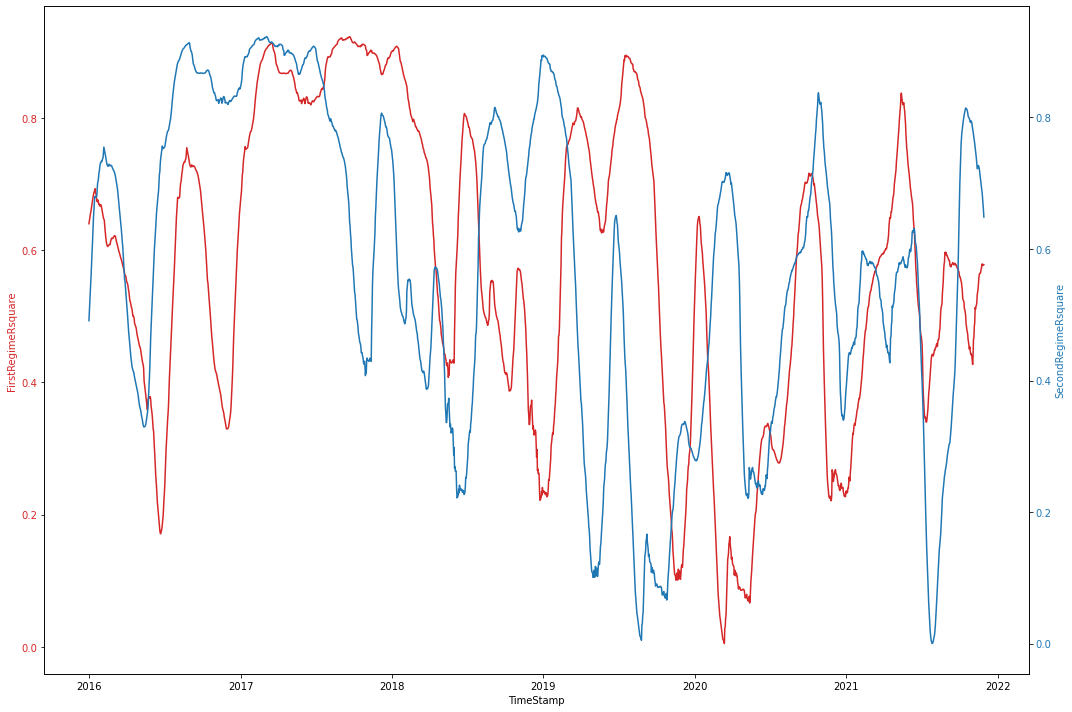

In [68]:
RsquareDf = pd.DataFrame(
    {'PivotDate': pivotDateList,
     'FirstRegimeRsquare': firstRegimeRsquaredList,
     'SecondRegimeRsquare':secondRegimeRsquaredList
    })

fig, ax1 = plt.subplots(figsize=(15,10))

color = 'tab:red'
ax1.set_xlabel('TimeStamp')
ax1.set_ylabel('FirstRegimeRsquare', color=color)
ax1.plot(RsquareDf['PivotDate'],RsquareDf['FirstRegimeRsquare'],label='MinerRevenue',color=color) 
ax1.tick_params(axis='y', labelcolor=color)
#ax1.set_yscale('log')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('SecondRegimeRsquare', color=color)  # we already handled the x-label with ax1
ax2.plot(RsquareDf['PivotDate'],RsquareDf['SecondRegimeRsquare'], color=color)
ax2.tick_params(axis='y', labelcolor=color)
#ax2.set_yscale('log')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

In [72]:
#Dividing data into regimes
pivot_date =  OptimalPivotDate
firstRegime = df3.loc[df3["TimeStamp"] < pivot_date]

firstRegime

,TimeStamp,MinerRevenue,Difficulty,Market Price,HashRate,MinerRevenue(BTC),RollingVol
0,2012-03-11 00:00:00,3.664537e+04,1.496979e+06,4.95,9.897223e+00,7403.105367,NaN
1,2012-03-12 00:00:00,5.031774e+04,1.496979e+06,4.98,1.257617e+01,10103.963295,NaN
2,2012-03-13 00:00:00,5.279293e+04,1.496979e+06,5.07,1.131111e+01,10412.807616,NaN
3,2012-03-14 00:00:00,4.582820e+04,1.496979e+06,5.42,1.026930e+01,8455.386978,NaN
4,2012-03-15 00:00:00,3.408271e+04,1.496979e+06,5.45,9.599562e+00,6253.708599,NaN
...,...,...,...,...,...,...,...
2715,2019-08-17 01:00:00,1.681876e+07,9.985348e+12,10359.44,6.353592e+07,1623.519937,0.002697
2716,2019-08-18 01:00:00,1.649732e+07,1.001680e+13,10214.52,6.274016e+07,1615.085525,0.002704
2717,2019-08-19 01:00:00,2.251242e+07,1.018349e+13,10317.60,8.251450e+07,2181.943108,0.002678
2718,2019-08-20 01:00:00,2.138194e+07,1.018349e+13,10917.26,7.745227e+07,1958.544619,0.002667


In [73]:
#Generating Correlation Matrix for first Regime
Corr_Matrix = firstRegime[firstRegime.columns.drop(['TimeStamp'])].corr()
Corr_Matrix.style.background_gradient(cmap='coolwarm').set_precision(4)

,MinerRevenue,Difficulty,Market Price,HashRate,MinerRevenue(BTC),RollingVol
MinerRevenue,1.0000,0.6187,0.9726,0.6418,-0.4367,-0.3778
Difficulty,0.6187,1.0000,0.7378,0.9927,-0.4971,-0.3551
Market Price,0.9726,0.7378,1.0000,0.7493,-0.5024,-0.3916
HashRate,0.6418,0.9927,0.7493,1.0000,-0.4913,-0.3551
MinerRevenue(BTC),-0.4367,-0.4971,-0.5024,-0.4913,1.0000,0.7163
RollingVol,-0.3778,-0.3551,-0.3916,-0.3551,0.7163,1.0000


In [74]:
secondRegime = df3.loc[df3["TimeStamp"] >= pivot_date]
secondRegime.reset_index(drop=True)

,TimeStamp,MinerRevenue,Difficulty,Market Price,HashRate,MinerRevenue(BTC),RollingVol
0,2019-08-22 01:00:00,1.824479e+07,1.018349e+13,10129.40,7.137758e+07,1801.171515,0.002665
1,2019-08-23 01:00:00,2.030322e+07,1.018349e+13,10111.98,7.745227e+07,2007.837893,0.002677
2,2019-08-24 01:00:00,2.091319e+07,1.018349e+13,10405.81,8.099583e+07,2009.761004,0.002664
3,2019-08-25 01:00:00,2.002305e+07,1.018349e+13,10143.80,7.846471e+07,1973.920446,0.002667
4,2019-08-26 01:00:00,1.805160e+07,1.018349e+13,10135.06,6.935268e+07,1781.104320,0.002676
...,...,...,...,...,...,...,...
925,2022-03-04 00:00:00,3.633393e+07,2.755033e+13,42464.40,1.903653e+08,855.632626,0.001308
926,2022-03-05 00:00:00,3.104514e+07,2.755033e+13,39141.25,1.684527e+08,793.156667,0.001302
927,2022-03-06 00:00:00,3.234770e+07,2.755033e+13,39399.58,1.794090e+08,821.016357,0.001301
928,2022-03-07 00:00:00,3.583683e+07,2.755033e+13,38407.69,2.026911e+08,933.063882,0.001297


In [75]:
#Generating Correlation Matrix for second Regime
Corr_Matrix = secondRegime[secondRegime.columns.drop(['TimeStamp'])].corr()
Corr_Matrix.style.background_gradient(cmap='coolwarm').set_precision(4)

,MinerRevenue,Difficulty,Market Price,HashRate,MinerRevenue(BTC),RollingVol
MinerRevenue,1.0000,0.6061,0.9606,0.6809,-0.3924,-0.6604
Difficulty,0.6061,1.0000,0.7077,0.8706,-0.6648,-0.5876
Market Price,0.9606,0.7077,1.0000,0.6823,-0.5918,-0.7305
HashRate,0.6809,0.8706,0.6823,1.0000,-0.4734,-0.5619
MinerRevenue(BTC),-0.3924,-0.6648,-0.5918,-0.4734,1.0000,0.5896
RollingVol,-0.6604,-0.5876,-0.7305,-0.5619,0.5896,1.0000


<b> First Regime - Model Fit </b>

In [76]:
x = np.log(firstRegime[['MinerRevenue(BTC)','Difficulty','HashRate']])
y = np.log(firstRegime['Market Price'])

# create and fit scaler
scaler = StandardScaler()
scaler.fit(x)
# scale data set
Xt = scaler.transform(x)
Scaled_Xt = pd.DataFrame(Xt, columns =x.columns)

X = sm.add_constant(Scaled_Xt)
mod = sm.OLS(y, X)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:           Market Price   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     7781.
Date:                Wed, 09 Mar 2022   Prob (F-statistic):               0.00
Time:                        09:49:54   Log-Likelihood:                -2786.0
No. Observations:                2720   AIC:                             5580.
Df Residuals:                    2716   BIC:                             5604.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 6.2919      0.01

<b> Second Regime - Model Fit </b>

In [78]:
#x = np.log(secondRegime[['MinerRevenue(BTC)','Difficulty','HashRate']])
x = np.log(secondRegime[['MinerRevenue(BTC)','Difficulty','HashRate']])
y = np.log(secondRegime['Market Price'].reset_index(drop=True))

# create and fit scaler
scaler = StandardScaler()
scaler.fit(x)
# scale data set
Xt = scaler.transform(x)
Scaled_Xt = pd.DataFrame(Xt, columns =x.columns)
Scaled_Xt

X = sm.add_constant(Scaled_Xt)
mod = sm.OLS(y, X)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:           Market Price   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     548.4
Date:                Wed, 09 Mar 2022   Prob (F-statistic):          8.78e-205
Time:                        09:51:22   Log-Likelihood:                -642.62
No. Observations:                 930   AIC:                             1293.
Df Residuals:                     926   BIC:                             1313.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 9.9071      0.01

 Regime Shift Tests:
 
 Miner Revenue in BTC
~Running Window 90 day Vol plot - identify pivot


Correlation btc vs S&P
t-test - rolling windows
ADF test - identify point of mean reversion

Explore Additional features:
 HHI? Concentration 
 
 Explore Logistic or other non Linear Regression Techniques

find arbitrary point  - rolling regression biggest R2 diff between regimes
new regime -> check effect of US interest rates, equity correlation